In [1]:
from solver_selection_thm.thm_physics import ModelTHM, initialize, run, params
from solver_selection_thm.selector import SolverSelector
from solver_selection_thm.solver_space import CategoricalChoices, NumericalChoices
from solver_selection_thm.performance_predictor import (
    PerformancePredictorPassiveAgressive,
    PerformancePredictorEpsGreedy,
    RewardEstimator,
)
from solver_selection_thm.solver_space import SolverSpace
from solver_selection_thm.pp_binding import (
    KNOWN_SOLVER_COMPONENTS_THM,
    SolverSelectionMixinTHM,
)
from thm_runscript import make_solver_space_scheme_fthm
import numpy as np
from matplotlib import pyplot as plt
from load_experiments_data import load_experiments_data_thm

/home/porepy/porepy/src/porepy/utils/ui_and_logging.py:45: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from tqdm.autonotebook import trange as progressbar_class  # type: ignore


In [2]:
import pickle
from itertools import count
from copy import copy


RUNS = ['0','1','2','8','9']
RUNS_RANDOM = ['8','9']
# RUNS = [20,21,22]

sim_data, perf_data, solver_selector = load_experiments_data_thm(runs=RUNS, random_selection=False)
sim_data_random, perf_data_random, solver_selector = load_experiments_data_thm(runs=RUNS_RANDOM, random_selection=True)

Num solvers: 448
Num solvers: 448
Num solvers: 448
Num solvers: 448
Num solvers: 448
Num solvers: 448
Num solvers: 448
failed to load RANDOM_run_9_fthm_xinj=0.0_yinj=0.5_zinj=0.5_xprod=0.52_yprod=0.5_zprod=0.5
failed to load RANDOM_run_9_fthm_xinj=0.0_yinj=0.5_zinj=0.5_xprod=0.7_yprod=1.0_zprod=0.5
failed to load RANDOM_run_9_fthm_xinj=0.48_yinj=0.5_zinj=0.5_xprod=0.7_yprod=0.5_zprod=0.5
failed to load RANDOM_run_9_fthm_xinj=0.48_yinj=0.5_zinj=0.5_xprod=1.0_yprod=0.5_zprod=0.5
failed to load RANDOM_run_9_fthm_xinj=0.48_yinj=0.5_zinj=0.5_xprod=0.7_yprod=0.0_zprod=0.5
failed to load RANDOM_run_9_fthm_xinj=0.48_yinj=0.5_zinj=0.5_xprod=0.52_yprod=0.5_zprod=0.5
failed to load RANDOM_run_9_fthm_xinj=0.48_yinj=0.5_zinj=0.5_xprod=0.7_yprod=1.0_zprod=0.5


In [3]:
from collections import defaultdict
import pandas as pd


def make_pandas(sim_data, perf_data, seq_ids):
    sim_data_dict = defaultdict(lambda: [])
    perf_data_dict = defaultdict(lambda: [])
    for seq_id, data_simulations, solver_selection_history_seq in zip(
        seq_ids, sim_data, perf_data
    ):
        sim_idx = -1
        for data_row in data_simulations:
            for data in data_row:
                sim_idx += 1

                for ts_idx, ts in enumerate(data):
                    for ls_idx, ls in enumerate(ts.linear_solves):
                        sim_data_dict["seq_id"].append(seq_id)
                        sim_data_dict["sim_idx"].append(sim_idx)
                        sim_data_dict["ts_idx"].append(ts_idx)
                        sim_data_dict["ls_idx"].append(ls_idx)
                        sim_data_dict["real_solve_time"].append(ls.linear_solve_time)
                        sim_data_dict["krylov_iters"].append(ls.krylov_iters)
                        sim_data_dict["petsc_converged_reason"].append(
                            ls.petsc_converged_reason
                        )
                        sim_data_dict["cfl"].append(ls.cfl)

        solver_selection_history = None
        for x in solver_selection_history_seq:
            if x is not None:
                solver_selection_history = x
        for reward_idx in range(len(solver_selection_history.reward)):
            perf_data_dict["seq_id"].append(seq_id)
            perf_data_dict["sim_idx"].append(sim_idx)
            perf_data_dict["reward"].append(
                solver_selection_history.reward[reward_idx]
            )
            perf_data_dict["expectation"].append(
                solver_selection_history.expectation[reward_idx]
            )
            perf_data_dict["decision_idx"].append(
                solver_selection_history.decision_idx[reward_idx]
            )
            perf_data_dict["features"].append(
                solver_selection_history.features[reward_idx]
            )
    return pd.DataFrame(data=sim_data_dict), pd.DataFrame(data=perf_data_dict)


ALL_RUNS = RUNS + [f"R{x}" for x in RUNS_RANDOM]

df_sim, df_perf = make_pandas(
    sim_data=sim_data + sim_data_random,
    perf_data=perf_data + perf_data_random,
    seq_ids=ALL_RUNS,
)
df_sim

,seq_id,sim_idx,ts_idx,ls_idx,real_solve_time,krylov_iters,petsc_converged_reason,cfl
0,0,0,0,0,-1,44,2,2.759354e-16
1,0,0,0,1,-1,42,2,5.925187e-03
2,0,0,0,2,-1,34,2,5.928433e-03
3,0,0,0,3,-1,74,2,5.928433e-03
4,0,0,1,0,-1,39,2,5.928433e-03
...,...,...,...,...,...,...,...,...
26763,R9,18,40,2,-1,39,2,1.755438e+00
26764,R9,18,41,0,-1,44,2,2.282069e+00
26765,R9,18,41,1,-1,77,2,2.282068e+00
26766,R9,18,41,2,-1,64,2,2.282068e+00


Text(0.5, 0, '# Linear solve')

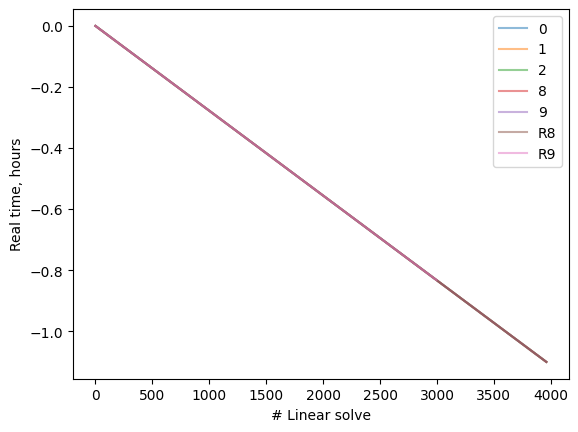

In [4]:
FAIL_REWARD = -100
HOUR = 60 * 60
DAY = 24 * HOUR

for seq_id in ALL_RUNS:
    seq_idx = np.array(df_sim.seq_id == seq_id)
    time = np.array(df_sim.real_solve_time)[seq_idx]
    plt.plot(np.cumsum(time) / HOUR, label=seq_id, alpha=0.5)
plt.legend()
plt.ylabel('Real time, hours')
plt.xlabel('# Linear solve')

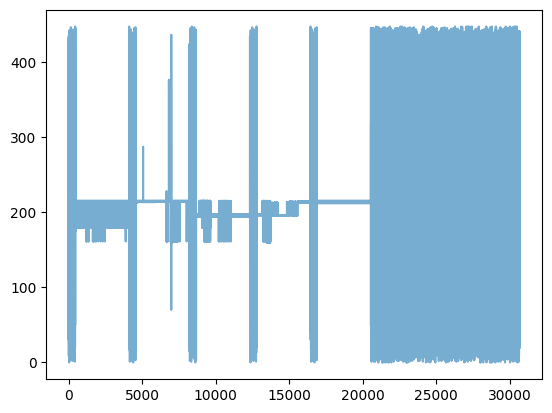

In [5]:
decision_id = np.array(df_perf.decision_idx)
_ = plt.plot(decision_id, label='Decision idx', alpha=0.6)

The number of successful solves is 3962, both for real and random.
This is because Random fails more, but proceeds only after success. And it needs to solve exactly this number of linear systems.

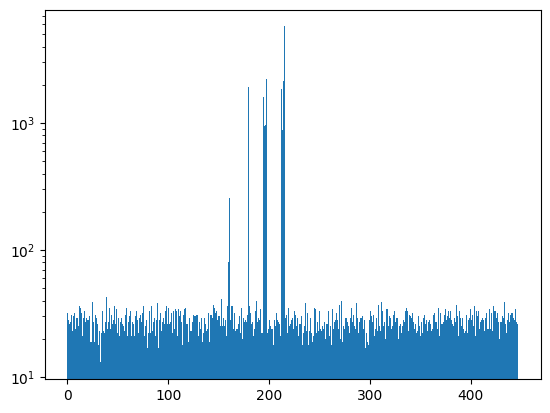

In [6]:
num_solvers = 448
_ = plt.hist(decision_id, bins=num_solvers, log=True)

In [7]:
FAIL_REWARD = -100
num_success = (df_perf.reward > FAIL_REWARD).sum()
print(num_success, df_perf.shape[0])
print(num_success / df_perf.shape[0])

26644 30668
0.8687883135515847


* Classifier - test on a SINGLE sequence. Random and simulation.
* Oracle - Use all data.
* Regressor cv on all data

In [15]:
X = np.stack(df_perf.features)
y = np.array(df_perf.reward)
success = y > FAIL_REWARD
Xsuccess = X[success]
ysuccess = y[success]
ycat = success
print(Xsuccess.shape, ysuccess.shape)

(26644, 35) (26644,)


In [16]:
from typing import Literal

classification_case: Literal["all", "one_seq", "random"] = "all"
if classification_case == "all":
    X_classification = X
    y_classification = ycat
elif classification_case == "one_seq":
    filter_ = np.array((df_perf.seq_id == "8"))
    X_classification = X[filter_]
    y_classification = ycat[filter_]
elif classification_case == "random":
    filter_ = np.array((df_perf.seq_id == "R8"))
    X_classification = X[filter_]
    y_classification = ycat[filter_]
else:
    raise ValueError(classification_case)

print(f"{classification_case = }", X_classification.shape, y_classification.shape)
print('success %:', y_classification.sum() / y_classification.size * 100)

classification_case = 'all' (30668, 35) (30668,)
success %: 86.87883135515847


In [17]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_validate
from sklearn.linear_model import SGDClassifier
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.utils.class_weight import compute_class_weight
from solver_selection_thm.performance_predictor import SuccessClassifier


classifier = SuccessClassifier()

scoring = ("accuracy", "f1")
cv_results = cross_validate(
    classifier,
    X_classification,
    y_classification,
    cv=5,
    scoring=scoring,
    return_train_score=True,
    return_estimator=True,
)
for score in scoring:
    print(score)
    print("Train scores:", cv_results[f"train_{score}"])
    print("Test scores:", cv_results[f"test_{score}"])
    print("Mean Train:", np.mean(cv_results[f"train_{score}"]))
    print("Mean Test:", np.mean(cv_results[f"test_{score}"]))
    print()

best_classifier_offline = cv_results["estimator"][np.argmax(cv_results["test_f1"])]
best_classifier_offline

accuracy
Train scores: [0.93531426 0.9242276  0.92981169 0.93780314 0.95675566]
Test scores: [0.88392566 0.97587219 0.97065536 0.93412685 0.60198924]
Mean Train: 0.9367824687470974
Mean Test: 0.8733138609746746

f1
Train scores: [0.96154871 0.95469058 0.95813479 0.9630991  0.97449826]
Test scores: [0.937346   0.98601663 0.98294162 0.96087546 0.7031497 ]
Mean Train: 0.9623942871088873
Mean Test: 0.9140658836603883



SuccessClassifier()

2. Training offline model with cross-validation and comparing its

In [20]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import KFold

def make_oracle_regressor():
    return GradientBoostingRegressor(random_state=42)
oracle = make_oracle_regressor()

scoring = ("r2", "neg_mean_absolute_error", "neg_mean_squared_error")
cv_results = cross_validate(
    oracle,
    Xsuccess.clip(-1e10, 1e10),
    ysuccess,
    cv=KFold(n_splits=5, shuffle=True, random_state=42),
    scoring=scoring,
    return_train_score=True,
    return_estimator=True,
    n_jobs=-1,
)

In [21]:
for score in scoring:
    print(score)
    print("Train scores:", cv_results[f"train_{score}"])
    print("Test scores:", cv_results[f"test_{score}"])
    print("Mean Train:", np.mean(cv_results[f"train_{score}"]))
    print("Mean Test:", np.mean(cv_results[f"test_{score}"]))
    print()

best_regressor_offline = cv_results["estimator"][np.argmax(cv_results["test_r2"])]
best_regressor_offline

r2
Train scores: [0.87064005 0.86885655 0.8734669  0.86555234 0.86785752]
Test scores: [0.84188077 0.87291426 0.85267915 0.87357224 0.86278021]
Mean Train: 0.8692746708879735
Mean Test: 0.8607653243419613

neg_mean_absolute_error
Train scores: [-0.05776217 -0.05774579 -0.05777741 -0.0578774  -0.05784174]
Test scores: [-0.05892097 -0.05831265 -0.05800763 -0.05806002 -0.05984906]
Mean Train: -0.05780090190058608
Mean Test: -0.058630066773776524

neg_mean_squared_error
Train scores: [-0.00559508 -0.00554103 -0.00561553 -0.00569394 -0.00557925]
Test scores: [-0.00655261 -0.00577613 -0.00543794 -0.00569612 -0.00625325]
Mean Train: -0.005604965230026989
Mean Test: -0.005943210538325064



,loss,'squared_error'
,learning_rate,0.1
,n_estimators,100
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


In [22]:
np.std(ysuccess)

0.20710260247275974

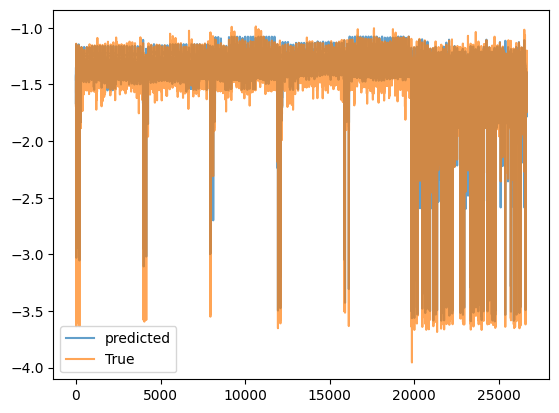

In [ ]:
plt.plot(best_regressor_offline.predict(Xsuccess.clip(-1e10, 1e10)), label='predicted', alpha=0.7)
plt.plot(ysuccess, label='True', alpha=0.7)
plt.legend()

Offline ranking score

In [32]:
from typing import Literal
ranking_case: Literal["all", 'one_seq', 'random'] = 'one_seq'
if ranking_case == 'all':
    X_ranking = Xsuccess
    y_ranking = ysuccess
elif ranking_case == 'one_seq':
    filter_ = np.array((df_perf.seq_id == "8") & (df_perf.reward > FAIL_REWARD))
    X_ranking = X[filter_]
    y_ranking = y[filter_]
elif ranking_case == 'random':
    filter_ = np.array((df_perf.seq_id == "R8") & (df_perf.reward > FAIL_REWARD))
    X_ranking = X[filter_]
    y_ranking = y[filter_]
else:
    raise ValueError(ranking_case)

print(f'{ranking_case = }', X_ranking.shape, y_ranking.shape)

ranking_case = 'one_seq' (3962, 35) (3962,)


In [38]:
from sklearn.model_selection import KFold
from solver_selection_thm.performance_predictor import RewardRegressor
from tqdm import tqdm

def stack_features_solvers(features: np.ndarray, solvers: np.ndarray) -> np.ndarray:
    dim0 = solvers.shape[0]
    dim1 = features.shape[0]
    features = np.broadcast_to(features, (dim0, dim1))
    return np.concatenate([features, solvers], axis=1)

oracle = make_oracle_regressor()
oracle.fit(Xsuccess.clip(-1e10, 1e10), ysuccess)  # oracle trains on full data anyway

kf = KFold(n_splits=5, shuffle=True, random_state=42)

all_solvers = solver_selector.solver_space.all_decisions_encoding
Xranking_features = X_ranking[:, : -all_solvers.shape[1]]  # removing solvers encoding

data_k_fold = []

for train_set, test_set in kf.split(X_ranking):
    estimator = RewardRegressor()
    estimator.fit(X_ranking[train_set], ysuccess[train_set])

    data_this = []
    data_k_fold.append(data_this)

    # ranking
    for test_idx in tqdm(test_set):
        x_to_predict = stack_features_solvers(Xranking_features[test_idx], all_solvers)

        # online
        ypred = estimator.predict(x_to_predict)

        # offline
        yoracle = oracle.predict(x_to_predict.clip(-1e10, 1e10))

        data_this.append({'yoracle': yoracle, 'ypred': ypred})

100%|██████████| 792/792 [00:00<00:00, 1475.00it/s]


In [39]:
def top_1_normalized_score(ypred, ytrue):
    i = np.argmax(ypred)
    s = ytrue[i]
    ymin, ymax = np.min(ytrue), np.max(ytrue)
    if ymax == ymin:
        return 0.0  # degenerate case: all ytrue values are equal
    else:
        return -1.0 + 2.0 * (s - ymin) / (ymax - ymin)
    
def top_eps_accuracy(ypred, ytrue, eps=1e-3):
    i = np.argmax(ypred)
    return abs(ytrue[i] - np.max(ytrue)) <= eps

In [40]:
mean_NTS = [np.mean([top_1_normalized_score(ypred=x['ypred'], ytrue=x['yoracle']) for x in data_test]) for data_test in data_k_fold]
print(mean_NTS)
np.mean(mean_NTS)

[0.8881675285353393, 0.5740547732137806, 0.5735143502952539, 0.5731934846344807, 0.5741876664639366]


0.6366235606285583

In [44]:
eps = 1e-1
mean_topeps = [np.mean([top_eps_accuracy(ypred=x['ypred'], ytrue=x['yoracle'], eps=eps) for x in data_test]) for data_test in data_k_fold]
print(mean_topeps)
print(np.mean(mean_topeps))

[0.46532156368221944, 0.0, 0.0, 0.0, 0.0]
0.09306431273644389


Incremental learning

In [46]:
class TwoEstimators:

    def __init__(self, classifier, regressor):
        self.classifier = classifier
        self.regressor = regressor

    def fit(self, X, y):
        success = y >= FAIL_REWARD
        self.classifier.fit(X, success)
        self.regressor.fit(X[success], y[success])

    def partial_fit(self, X, y):
        X = np.array(X).reshape(1, -1)
        y = np.atleast_1d(y)
        success = y >= FAIL_REWARD
        self.classifier.partial_fit(X, success)
        if success:
            self.regressor.partial_fit(X[success], y[success])

    def predict(self, X):
        reward_estimate = np.full(X.shape[0], FAIL_REWARD, dtype=float)
        success_estimate = self.classifier.predict(X)
        if not np.any(success_estimate):
            return reward_estimate

        reward_estimate[success_estimate] = self.regressor.predict(X[success_estimate])
        return reward_estimate

In [97]:
from typing import Literal
incremental_case: Literal["all", 'one_seq', 'random'] = 'one_seq'
expectations = None
if incremental_case == 'all':
    Xincr = X
    yincr = y
elif incremental_case == 'one_seq':
    filter_ = np.array((df_perf.seq_id == "8"))
    Xincr = X[filter_]
    yincr = y[filter_]
    expectations = np.array(df_perf.expectation)[filter_][num_solvers:]
elif incremental_case == 'random':
    filter_ = np.array((df_perf.seq_id == "R8"))
    Xincr = X[filter_]
    yincr = y[filter_]
else:
    raise ValueError(incremental_case)

Xoffline = Xincr[:num_solvers]
yoffline = yincr[:num_solvers]
Xonline = Xincr[num_solvers:]
yonline = yincr[num_solvers:]

print(f'{incremental_case = }', Xoffline.shape, Xonline.shape)

incremental_case = 'one_seq' (448, 35) (3659, 35)


Sanity check -- the predictor here does exactly the same result on the same data as in the real sim.

In [84]:
if expectations is not None:
    regressor_online = TwoEstimators(classifier=SuccessClassifier(), regressor=RewardRegressor())
    regressor_online.fit(Xoffline, yoffline)

    reward_expected = []

    for Xbatch, ybatch in zip(Xonline, yonline):
        # online
        ypred_expected = regressor_online.predict(Xbatch.reshape(1, -1))

        # feedback
        solve_time = np.exp(-ybatch)
        regressor_online.partial_fit(Xbatch.reshape(1, -1), [ybatch])

        # saving stats
        reward_expected.append(ypred_expected.item())

    assert np.allclose(reward_expected, expectations, rtol=1e-10, atol=1e-10)

In [98]:
from time import time

oracle = TwoEstimators(
    classifier=SuccessClassifier(), regressor=make_oracle_regressor()
)
oracle.fit(X.clip(-1e10, 1e10), y)

all_solvers = solver_selector.solver_space.all_decisions_encoding
Xonline_features = Xonline[:, : -all_solvers.shape[1]]  # removing solvers encoding

regressor_online = TwoEstimators(
    classifier=SuccessClassifier(), regressor=RewardRegressor()
)
regressor_online.fit(Xoffline, yoffline)

data_incremental = []

for Xfeature in tqdm(Xonline_features):
    x_to_predict = stack_features_solvers(Xfeature, all_solvers)

    # online
    tpred = time()
    predictions_online = regressor_online.predict(x_to_predict)
    max_score_idx_online = np.argmax(predictions_online)
    tpred = time() - tpred

    # offline
    predictions_offline = best_regressor_offline.predict(x_to_predict.clip(-1e10, 1e10))

    # feedback
    X_feedback = x_to_predict[max_score_idx_online].reshape(1, -1)
    y_feedback = predictions_offline[max_score_idx_online]
    tfeedback = time()
    regressor_online.partial_fit(X_feedback, [y_feedback])
    tfeedback = time() - tfeedback

    # saving stats
    data_incremental.append(
        {
            "ypred": predictions_online,
            "yoracle": predictions_offline,
            "tpred": tpred,
            "tfeedback": tfeedback,
        }
    )

100%|██████████| 3659/3659 [00:09<00:00, 392.87it/s]


(-2.0, -1.0)

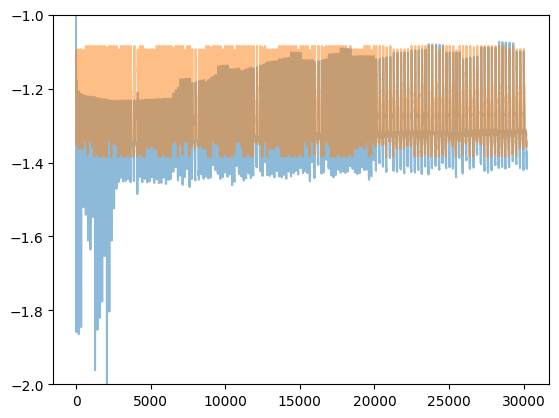

In [96]:
plt.plot([max(x["ypred"]) for x in data_incremental], label="ypred", alpha=0.5)
plt.plot([max(x["yoracle"]) for x in data_incremental], label="yoracle", alpha=0.5)
plt.ylim(-2, -1)

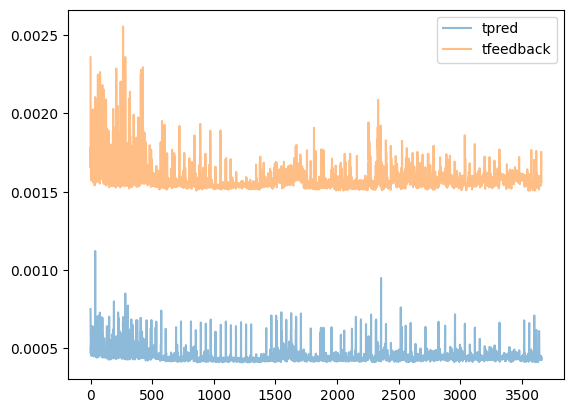

In [101]:
plt.plot([(x["tpred"]) for x in data_incremental], label="tpred", alpha=0.5)
plt.plot([(x["tfeedback"]) for x in data_incremental], label="tfeedback", alpha=0.5)
plt.legend()

0.9282677312901669


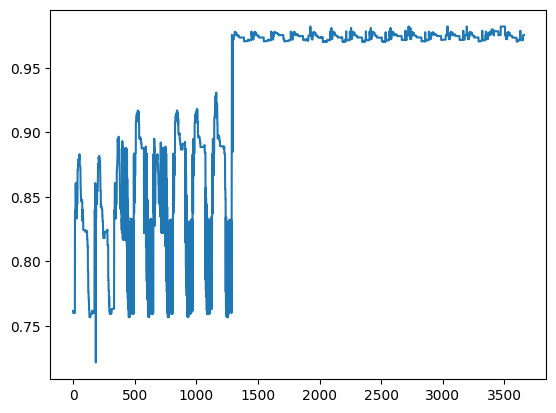

In [102]:
ntf = [top_1_normalized_score(ypred=x['ypred'], ytrue=x['yoracle']) for x in data_incremental]
plt.plot(ntf)
mean_NTS = np.mean(ntf)
print(mean_NTS)

eps = 1e-02, mean_topeps = 0.00
eps = 2e-02, mean_topeps = 0.15
eps = 5e-02, mean_topeps = 0.65
eps = 1e-01, mean_topeps = 0.77
eps = 2e-01, mean_topeps = 1.00


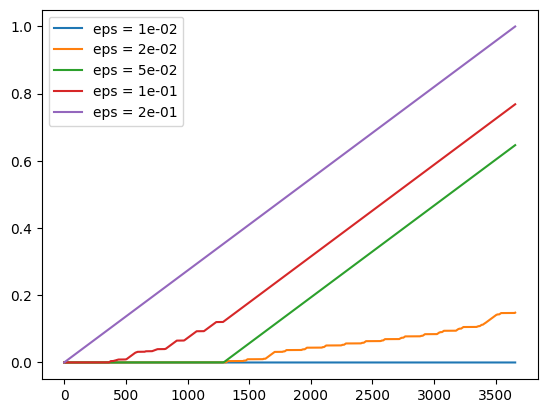

In [103]:
for eps in [1e-2, 2e-2, 5e-2, 1e-1, 2e-1]:
    topeps = [top_eps_accuracy(ypred=x['ypred'], ytrue=x['yoracle'], eps=eps) for x in data_incremental]
    plt.plot(np.cumsum(topeps) / len(topeps), label=f'{eps = :.0e}')
    mean_topeps = np.mean(topeps)
    print(f'{eps = :.0e}, {mean_topeps = :.2f}')
plt.legend()
# plt.grid()

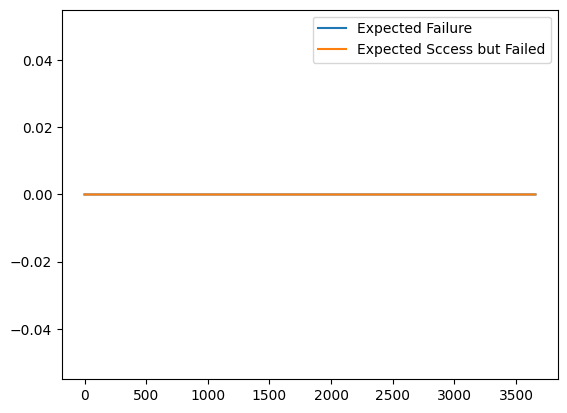

In [106]:
ef = [max(x["yoracle"]) <= FAIL_REWARD for x in data_incremental]
esbf = [
    max(x["yoracle"]) > FAIL_REWARD
    and x["yoracle"][np.argmax(x["ypred"])] <= FAIL_REWARD
    for x in data_incremental
]
plt.plot(ef, label='Expected Failure')
plt.plot(esbf, label='Expected Sccess but Failed')
plt.legend()

Regret: 215.37964180444982


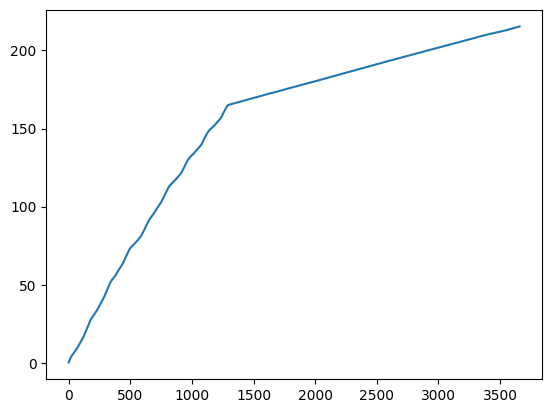

In [110]:
regret = [max(x['yoracle']) - x["yoracle"][np.argmax(x["ypred"])] for x in data_incremental]
plt.plot(np.cumsum(regret))
print('Regret:', np.sum(regret))

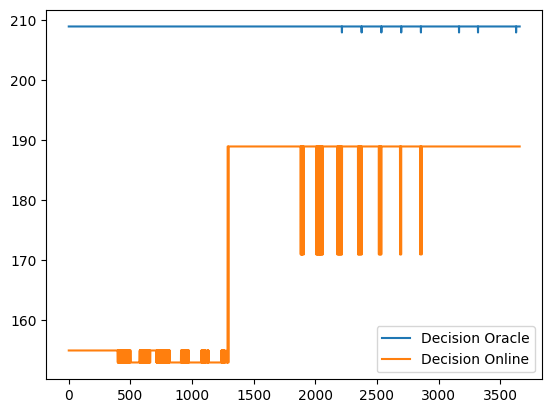

In [112]:
plt.plot([np.argmax(x['yoracle']) for x in data_incremental], label='Decision Oracle')
plt.plot([np.argmax(x['ypred']) for x in data_incremental], label='Decision Online')
plt.legend()

# LEFT HERE 07.08.25

<BarContainer object of 26 artists>

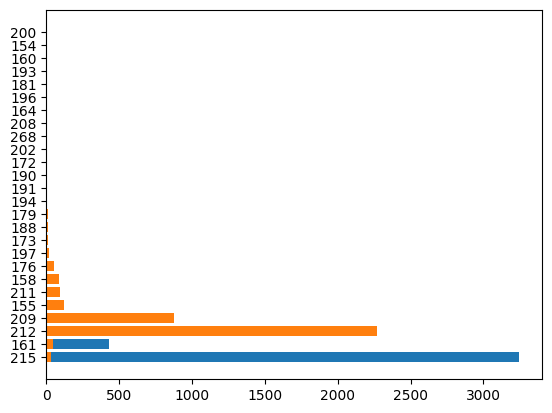

In [28]:
def count_decision_frequency(decisions, threshold=0):
    num_seleced = np.zeros(num_solvers)
    np.add.at(num_seleced, decisions, 1)
    frequent_solver_idx = np.argsort(num_seleced)[::-1]
    frequent_solver_idx = frequent_solver_idx[num_seleced[frequent_solver_idx] > threshold]
    return num_seleced, frequent_solver_idx

num_selected_offline, frequent_solver_idx_offline = count_decision_frequency(decisions_offline)
num_selected_online, frequent_solver_idx_online = count_decision_frequency(decisions_online)

plt.barh(frequent_solver_idx_online.astype(str), num_selected_online[frequent_solver_idx_online])
plt.barh(frequent_solver_idx_offline.astype(str), num_selected_offline[frequent_solver_idx_offline])

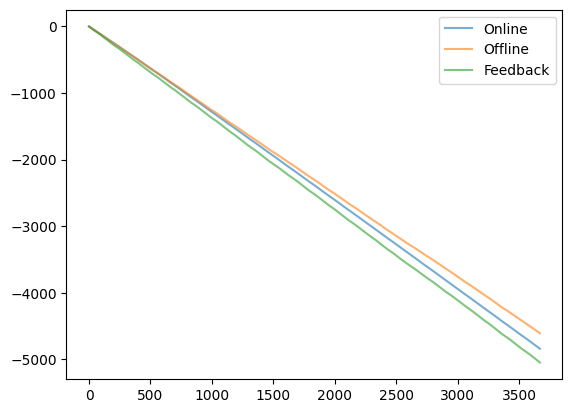

In [54]:
plt.plot(np.cumsum(reward_online), label='Online', alpha=0.6)
plt.plot(np.cumsum(reward_offline), label='Offline', alpha=0.6)
plt.plot(np.cumsum(reward_feedback), label='Feedback', alpha=0.6)
# plt.plot(np.cumsum(common_history.reward[sep:]), label='Real', alpha=0.6)
plt.legend()

# How many times each solver was used?

array([1843., 1829.])

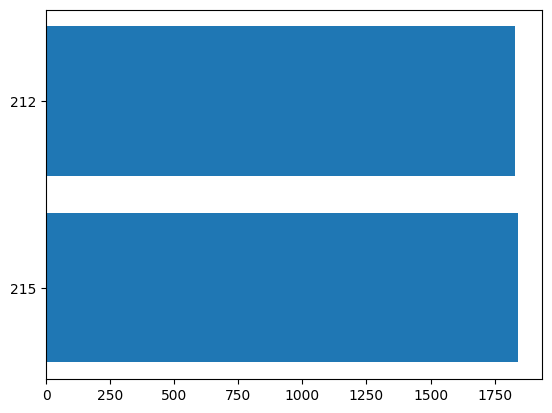

In [30]:
num_seleced, frequent_solver_idx = count_decision_frequency(common_history.decision_idx, threshold=1)

plt.barh(frequent_solver_idx.astype(str), num_seleced[frequent_solver_idx])
num_seleced[frequent_solver_idx]

/home/porepy/.local/lib/python3.11/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/porepy/.local/lib/python3.11/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


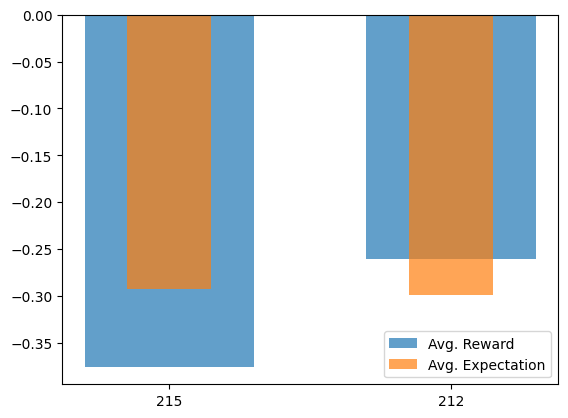

In [31]:
rewards_for_class = [[] for i in range(num_solvers)]
expectations_for_class = [[] for i in range(num_solvers)]


for reward, expectation, reward, solver_id in zip(y, common_history.expectation, common_history.reward, decision_id):
    if (-50 <= expectation <= 50 and -50 <= reward <= 50):
        rewards_for_class[solver_id].append(reward)
        expectations_for_class[solver_id].append(expectation)

avg_expectation_for_class = np.array([np.mean(x) for x in expectations_for_class])
avg_reward_for_class = np.array([np.mean(x) for x in rewards_for_class])

min_reward = -1
plt.bar(frequent_solver_idx.astype(str), avg_reward_for_class[frequent_solver_idx] - min_reward, alpha=0.7, width=0.6, label='Avg. Reward')
plt.bar(frequent_solver_idx.astype(str), avg_expectation_for_class[frequent_solver_idx] - min_reward, alpha=0.7, width=0.3, label='Avg. Expectation')
# plt.ylim(-2, 0.5)
plt.legend()

Transition matrix

In [32]:
from collections import defaultdict

category_to_idx = defaultdict(lambda: len(frequent_solver_idx)) | {x: i for i, x in enumerate(frequent_solver_idx)}
category_to_idx 

defaultdict(<function __main__.<lambda>()>, {215: 0, 212: 1})

In [33]:
M = np.zeros((frequent_solver_idx.size + 1, frequent_solver_idx.size + 1))
for a, b in zip(decision_id[:-1], decision_id[1:]):
    M[category_to_idx[a], category_to_idx[b]] += 1

P = M / M.sum(axis=1, keepdims=True)

Text(0.5, 1.0, 'P(next = (column) | current = (row))')

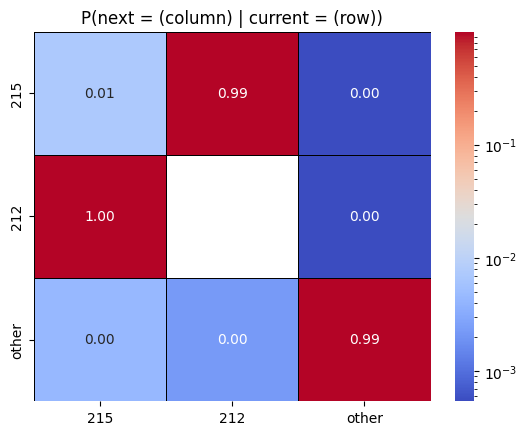

In [34]:
import seaborn as sns

labels = list(frequent_solver_idx.astype(str)) + ['other']

sns.heatmap(
    P,
    yticklabels=labels,
    xticklabels=labels,
    annot=True,
    fmt='.2f',
    norm="log",
    cmap="coolwarm",              # apply coolwarm palette
    linecolor="black",            # black grid lines
    linewidths=0.5                # line width > 0 to make lines visible
)
plt.title('P(next = (column) | current = (row))')

Assuming only one solver was allowed, what reward would we get if we chose system-AMG?

In [35]:
def stack_features_solvers(features: np.ndarray, solvers: np.ndarray) -> np.ndarray:
    dim0 = solvers.shape[0]
    dim1 = features.shape[0]
    features = np.broadcast_to(features, (dim0, dim1))
    return np.concatenate([features, solvers], axis=1)


regressor_offline = TwoEstimators(classifier=SuccessClassifier(), regressor=RandomForestRegressor(criterion='squared_error', random_state=42))
regressor_offline.fit(X.clip(-1e10, 1e10), y)

all_solvers = solver_selector.solver_space.all_decisions_encoding
Xonline_features = Xonline[:, : -all_solvers.shape[1]]  # removing solvers encoding
Xonline_features.shape


reward_solvers = np.zeros((Xonline_features.shape[0], num_solvers))

for i, Xfeature in enumerate(Xonline_features[:]):
    x_to_predict = stack_features_solvers(Xfeature, all_solvers)

    # offline
    predictions_offline = regressor_offline.predict(x_to_predict.clip(-1e10, 1e10))
    reward_solvers[i] = predictions_offline
    

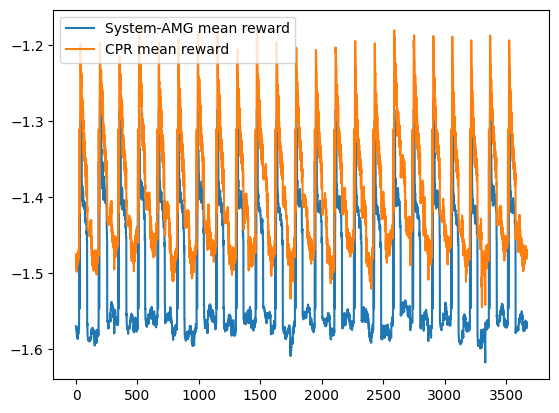

In [36]:
amg_rewards = reward_solvers[:, :123]
sorted_solver_ids = np.argsort(np.sum(amg_rewards,axis=0))[::-1][:110]  # 780
mean_amg_reward = np.mean(amg_rewards[:, sorted_solver_ids], axis=1)
plt.plot(mean_amg_reward, label='System-AMG mean reward')

cpr_rewards = reward_solvers[:, 123:]
sorted_solver_ids = np.argsort(np.sum(cpr_rewards,axis=0))[::-1][:110]  # 780
mean_cpr_reward = np.mean(cpr_rewards[:, sorted_solver_ids], axis=1)
plt.plot(mean_cpr_reward, label='CPR mean reward')

plt.legend()